In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv("../figures/model_performance_summary.csv")

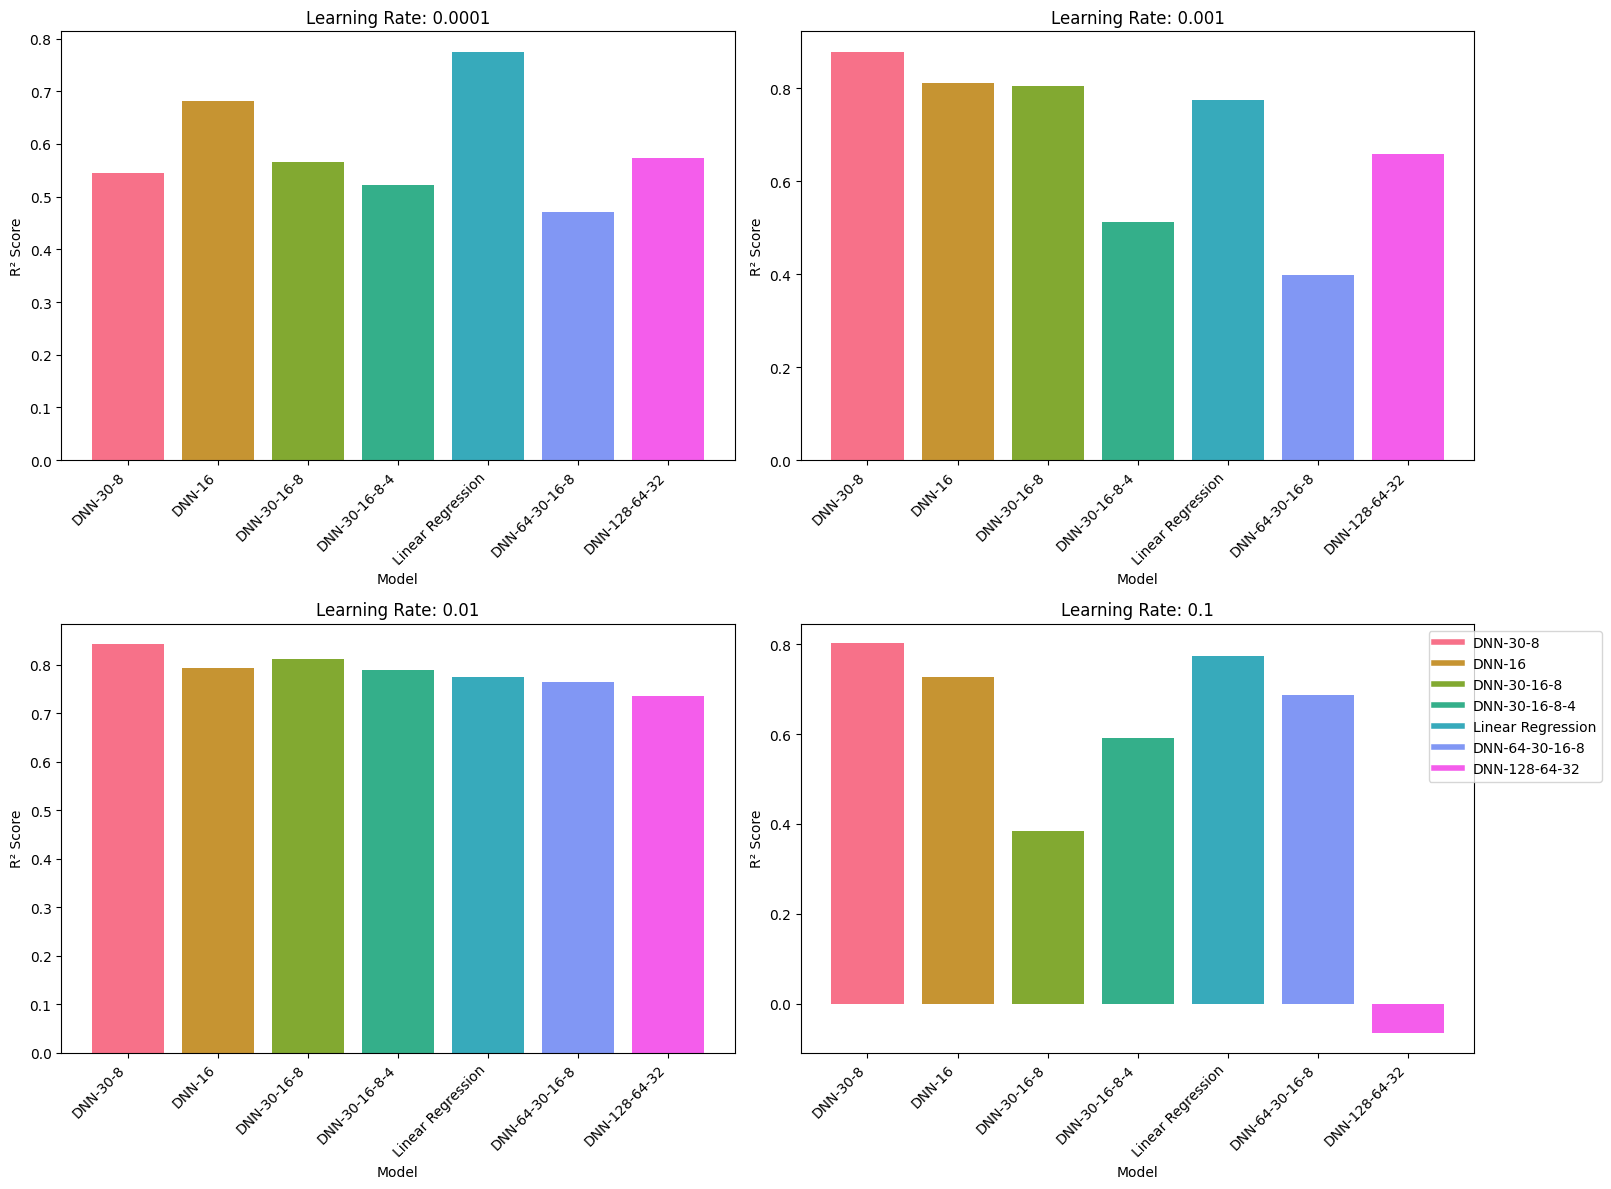

In [4]:
lrs = sorted(df["learning rate"].unique())
models = df["model"].unique()

color_map = {model: color for model, color in zip(models, sns.color_palette("husl", len(models)))}

plt.figure(figsize=(16, 12))
for idx, lr in enumerate(lrs):
    plt.subplot(2, 2, idx + 1) 
    model_scores = []
    for model in models:
        row = df[(df["model"] == model) & (df["learning rate"] == lr)]
        model_scores.append(row["r2"].values[0])
    bars = plt.bar(models, model_scores, color=[color_map[model] for model in models]) 
    plt.title(f"Learning Rate: {lr}")
    plt.xlabel("Model")
    plt.ylabel("R² Score")
    plt.xticks(rotation=45, ha='right')

handles = [plt.Line2D([0], [0], color=color_map[model], lw=4) for model in models]
plt.legend(handles, models, loc='upper right', bbox_to_anchor=(1.2, 1))
plt.tight_layout()
plt.savefig("../figures/model_performance_summary.png")
plt.show()

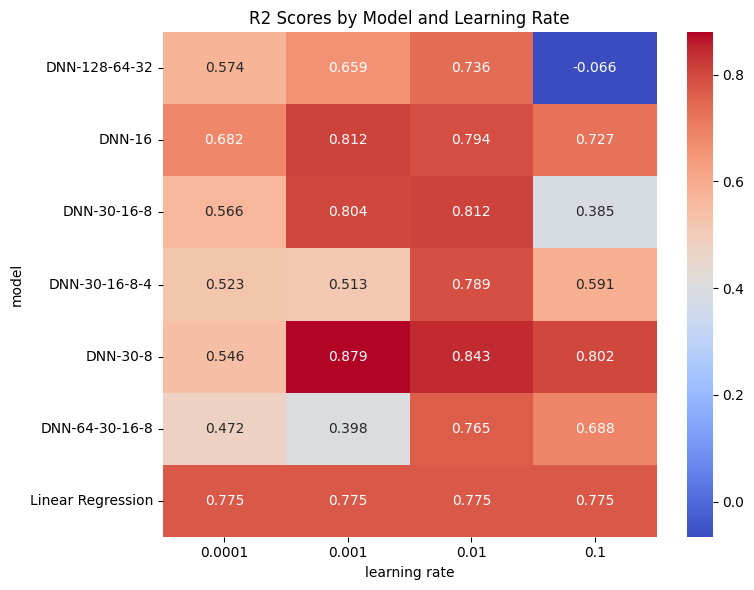

In [6]:
pivot = df.pivot(index="model", columns="learning rate", values="r2")

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="coolwarm")
plt.title("R2 Scores by Model and Learning Rate")
plt.tight_layout()
plt.savefig("../figures/r2_scores_heatmap.png")
plt.show()